## Premature Mortality < 65 (Anteil Todesfälle unter 65)
Ziel dieses Abschnitts ist es für jedes Land und jedes Jahr den Anteil der Todesfälle zu berechnen, dievor dem 65. Lbenensjahr aufgetreten sind.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

### Todesfälle unter 65 berechnen
Für jede einzelne Row summieren wir alle Todesfälle in den Altersklassen 0 bis 64. Da manche Länder pro Jahr mehrere Einträge haben aggregieren wir die Daten nach Country und Year. Für jedes Jahr berechnen wir deaths_u65 und deaths_total. Damit können wir dann p_u65 berechnen. 

In [3]:
age_u65 = ["Deaths at age 0","Deaths at age 1","Deaths at age 2","Deaths at age 3","Deaths at age 4","Deaths at age 5-9","Deaths at age 10-14","Deaths at age 15-19","Deaths at age 20-24","Deaths at age 25-29","Deaths at age 30-34","Deaths at age 35-39","Deaths at age 40-44","Deaths at age 45-49","Deaths at age 50-54","Deaths at age 55-59","Deaths at age 60-64"]

df["deaths_u65_row"] = df[age_u65].sum(axis=1)

grouped = df.groupby(["Country", "Year"]).agg(deaths_u65_total=("deaths_u65_row", "sum"), deaths_all_total=("Deaths at all ages", "sum"),).reset_index()

grouped["p_u65"] = grouped["deaths_u65_total"] / grouped["deaths_all_total"]


grouped = grouped.dropna(subset=["p_u65"])

print(grouped.head())

    Country  Year  deaths_u65_total  deaths_all_total     p_u65
0  Anguilla  2000              26.0               144  0.180556
1  Anguilla  2001              28.0               104  0.269231
2  Anguilla  2002              42.0               114  0.368421
3  Anguilla  2003              50.0               140  0.357143
4  Anguilla  2004              22.0                96  0.229167


### Missing Values prüfen

Zuerst zäheln wir für jedes Jahr, in wie vielen Ländern die Quote p_u65 berechnet werden konnte. Die folgende Grafik zeigt die Anzahl Länder mit gültigem Eintrag pro Jahr.

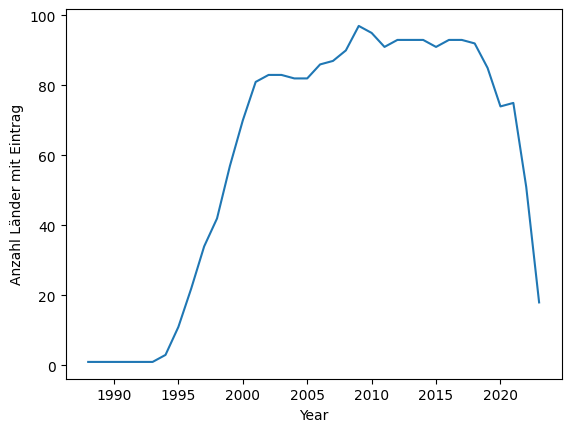

In [4]:
anzahl_länder_pro_jahr = grouped.groupby("Year")["Country"].nunique().reset_index(name="n_countries")
plt.figure()
plt.plot(anzahl_länder_pro_jahr["Year"], anzahl_länder_pro_jahr["n_countries"])
plt.xlabel("Year")
plt.ylabel("Anzahl Länder mit Eintrag")
plt.show()



Die Abbildung zeigt, dass vor Mitter der 1995 Jahre kaum Länder vollständige Mortalitätsdaten meldeten. Zwischen 2000 und 2018 liegt die Zahl der Länder mit gültigem p_u65 relativ stabil. Danach bricht die Kruve wieder ein, vermutlich weil neuere Daten noch nicht alle gemeledet wurden. 

#### Missingness-Heatmap
In dieser Heatmap wollen wir herausfinden welche Länder in welchen Jahren fehlen. Dazu erstellen wir eine Heatmap, in der jedes Feld einem Land/Jahr Paar entspricht
weiss = Daten vorhanden
rot = daten fehlen
Diese Darstellung zeigt uns nun ob einzelne Länder, Zeiträume systematisch unvollständig sind.

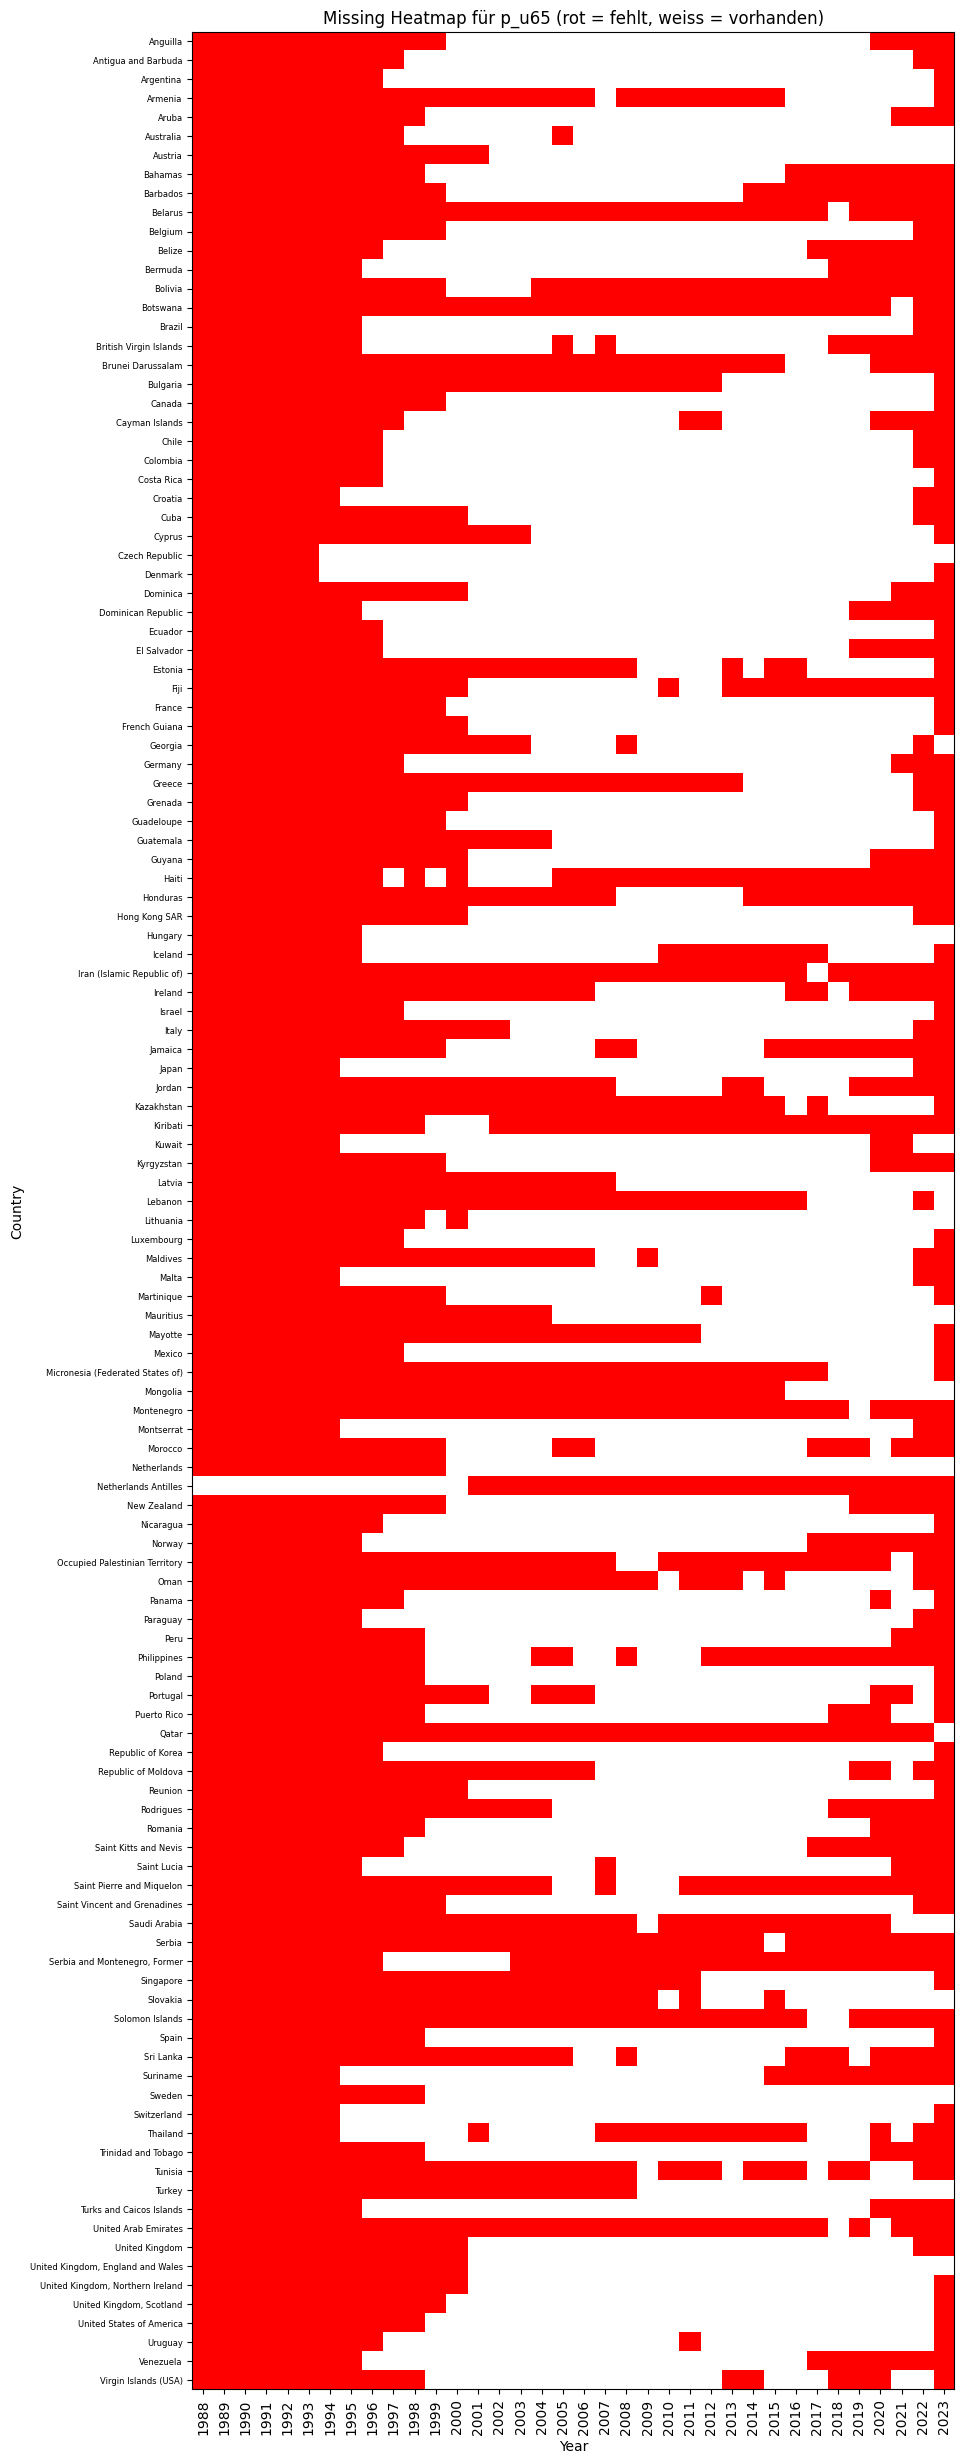

In [5]:
missing_matrix = grouped.pivot_table(index="Country", columns="Year", values="p_u65", aggfunc="mean")
missing_bool = missing_matrix.isna().astype(int)

cmap = mcolors.ListedColormap(["white", "red"])
plt.figure(figsize=(10, 25))
plt.imshow(missing_bool, aspect='auto', cmap=cmap)

# Achsen-Beschriftungen
plt.xlabel("Year")
plt.ylabel("Country")
plt.title("Missing Heatmap für p_u65 (rot = fehlt, weiss = vorhanden)")

# X-Ticks
plt.xticks(
    ticks=range(len(missing_bool.columns)),
    labels=missing_bool.columns,
    rotation=90
)

# Y-Ticks
plt.yticks(
    ticks=range(len(missing_bool.index)),
    labels=missing_bool.index,
    fontsize=6
)
plt.tight_layout(pad=2)
plt.show()


Die Heatmap bestätigt das Muster, das wir bereits im vorherigen Plot erkannt haben. Viele Länder vor 1995 haben praktisch keine Daten. Von 1998 - 2018 ist die Datenlage deutlich besser. Ab 2020 treten dann wieder verstärkt Lücken auf. 

## Histogramm und KDE von p_u65 im Jahr 2026
Nachdem wir überprüft habe, in welchen Jahren die meisten Länder Daten lieferten, fokussieren wir und hier auf das Jahr 2016, da diese eine gute Daten Abdeckung hat. 

Wir fokussieren uns hier auf die Verteilugn von p_u65 im Jahr 2016. 
Das Histogramm zeigt, wie häufig verschiedene p-Werte unter den Ländern vorkommen
Die KDE-Kurve gibt eine Schätzung der der Wahrscheinlichkeitsdichte

Wir wollen dabei erkennen, wie die Verteilung ist, ob es Ausreisser gibt und in welchem Bereich sich die meisten Länder bewegen

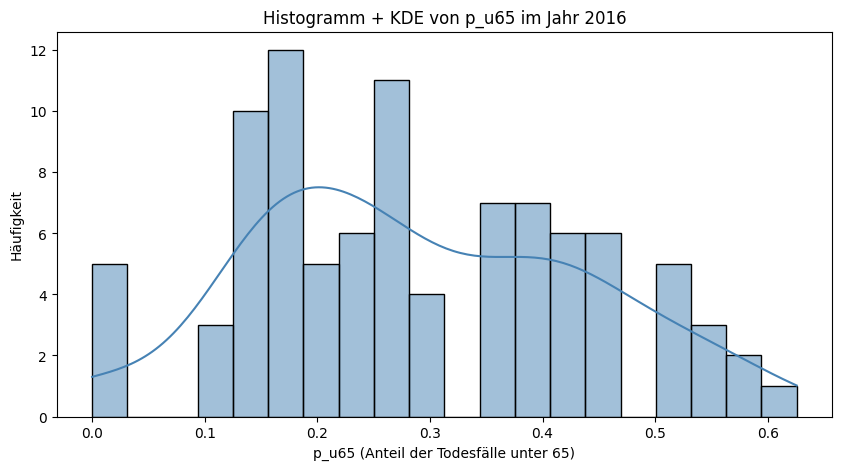

In [6]:
df_2016 = grouped[grouped["Year"] == 2016].dropna(subset=["p_u65"])

plt.figure(figsize=(10, 5))
sns.histplot(df_2016["p_u65"], bins=20, kde=True, color="steelblue")

plt.title("Histogramm + KDE von p_u65 im Jahr 2016")
plt.xlabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.ylabel("Häufigkeit")
plt.show()

Das Histogramm zeigt eine klare schiefe Verteilung. Die meisten Länder liegen im Bereich 0.15 bis 0.35. Es gibt einen langen rechten Schwanz. Einige Länder haben deutlich höhere p-Werte und daher einen höheren Anteil an Todesfällen unter 65. Es gibt auch einige sehr niedrige Werte. Bei den Werte nahe bei 0, handelt es sich möglicherweise um Datenfehler. 
Die KDE Kurve bestätigt ein Peak um etwa 0.2 und dann gibt es ein langsames abfallen Richtung 0.6

## ECDF von p_u65 im Jahr 2016
Um die Verteilung von p_u65 genauer zu beschreiben, verwenden wir zusätzlich ein ECDF

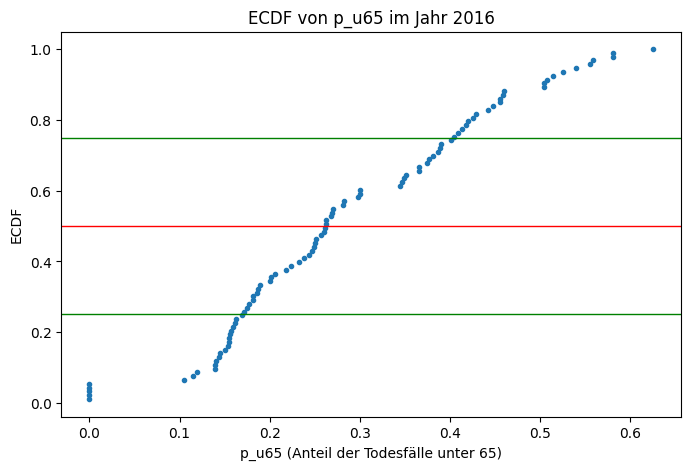

Median: 0.26
Q1: 0.17
Q2: 0.41


In [ ]:
x = np.sort(df_2016["p_u65"])
y = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, marker=".", linestyle="none")

plt.xlabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.ylabel("ECDF")
plt.title("ECDF von p_u65 im Jahr 2016")

plt.axhline(0.5, color="red", linewidth=1)
plt.axhline(0.25, color="green", linewidth=1)
plt.axhline(0.75, color="green",linewidth=1)
plt.show()

median_2016 = np.median(x)
q1_2016 = np.percentile(x, 25)
q3_2016 = np.percentile(x, 75)

print(f"Median: {median_2016:.2f}")
print(f"Q1: {q1_2016:.2f}")
print(f"Q2: {q3_2016:.2f}")


Die ECDF zeigt die Verteilung des Anteils der Todesfälle unter 65 Jahren über alle Länder im Jahr 2016.
Median: 0.26
Q1: 0.17
Q2: 0.41
Damit liegt die Hälfte der Länder zwischen 17% und 41%

Einige Länder haben einen Wert von 0.0. Diese Werte sind sehr wahrscheinlich Datenprobleme und spiegeln keine realistische Mortalität wieder. Wir werden sie später als Ausreisser markieren und entscheiden ob wir sie löschen.